### how many fakes do you get when you test thousands of genes, and which correction removes them without throwing away the real ones?

In [1]:
import numpy as np
from scipy import stats
import seaborn as sns
import matplotlib.pyplot as plt

about 500 will be significant: 10000 x 0.05, bellcurve around 0.5 if all values lay between 0 and 1
Prediction was partly wrong: 544 were false positives so this part was predicted right, but we see a uniformly distributed histogram instead of a bellcurve. 

In [2]:
rng = np.random.default_rng(42)
group_a = rng.normal(size=(10000, 5))
group_b = rng.normal(size=(10000, 5))

In [3]:
group_a.shape

(10000, 5)

In [4]:
results = stats.ttest_ind(group_a, group_b,axis=1)
p_values = results.pvalue

In [5]:
p_values.shape

(10000,)

In [6]:
significant = (p_values < 0.05)
significant.sum()

np.int64(544)

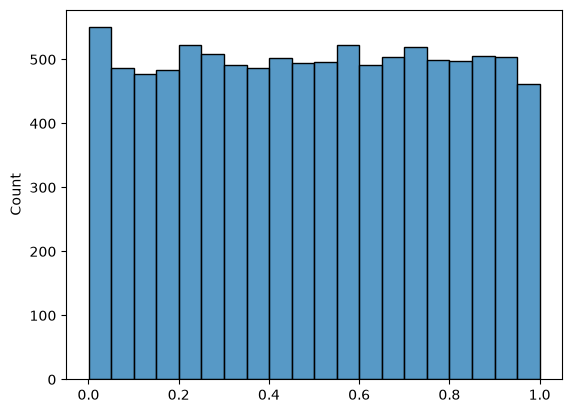

In [7]:
histogram = sns.histplot(p_values, bins=20)

As seen the 10000 tests are uniformly distributed over all the p-values. We see the biggest peak at the lowest p-value but this will be normal sampling noise. A p-value is just the chance to get a certain place on the curve and if nothing is going on then every chance is the same. with p = 0.5 that means that 50 percent of p-values should fall below it. If p = 0.8, 80 percent falls below it. So with 10000 tests and p = 0.05, we expect 500 tests to be false positives. 

#### Part 2

In [8]:
group_b_signal = group_b.copy()
group_b_signal[:1000] = group_b_signal[:1000] + 2

Because we add 2 to the first 1000 genes, there will be more significant genes this time. 

In [9]:
results = stats.ttest_ind(group_a, group_b_signal,axis=1)
p_values_signal = results.pvalue

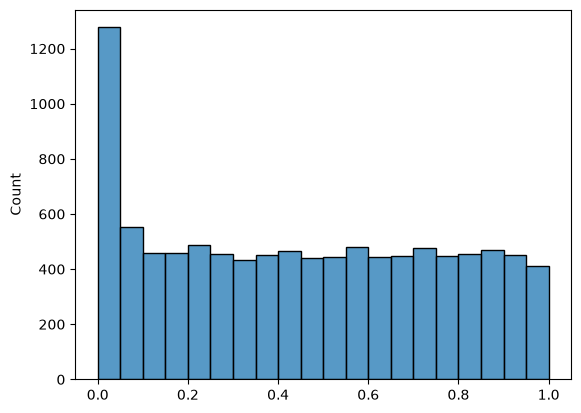

In [10]:
histogram = sns.histplot(p_values_signal, bins=20)

Only 789 of the 1000, 2 added genes are found. Because we still have 9000 normal genes, 9000 x 0.05 = 450 will still be false positives. 

In [11]:
is_real = np.zeros(10000, dtype=bool)
is_real[:1000] = True

In [12]:
is_real.sum()

np.int64(1000)

In [13]:
significant_signal = p_values_signal < 0.05

In [14]:
true_positives = (significant_signal & is_real).sum()
true_positives

np.int64(789)

In [15]:
false_positives = (significant_signal & ~is_real).sum()
false_positives

np.int64(488)

789 are true positives, 488 are false positives versus the 450 we predicted. This is normal noise. 38 percent of the significant list is still fake. So we cannot just use the significant values to be sure of our experiment. Even tho we have an effect, a lot of the genes are still false positives.

In [16]:
check = p_values_signal < 0.000005
check.sum()

np.int64(3)

This is used if we want 0 false positives, but too many true positives are thrown away. 
This is Bonferroni, 3 of the 789 real genes are kept. 

#### Benjamini-Hochberg

In [18]:
order = np.argsort(p_values_signal)
m = len(p_values_signal)
rank = np.arange(1, m + 1)
sorted_p = p_values_signal[order]
thresholds = (rank/m) * 0.05


In [19]:
passes = sorted_p <= thresholds
passes


array([ True,  True,  True, ..., False, False, False], shape=(10000,))

In [20]:
positions = np.nonzero(passes)[0]
positions


array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 25, 26, 27, 28, 29,
       30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46,
       47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63,
       64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 80, 81])

In [21]:
k = positions.max() +1
k


np.int64(82)

In [24]:
bh_sorted = rank <= k
passing = np.zeros(m, dtype=bool)
passing[order] = bh_sorted
passing.sum()

np.int64(82)

k = 82 out of 1200 plus, I think these will all be true positives. 

In [25]:
bh_true_positives = (passing & is_real).sum()
bh_true_positives

np.int64(82)

In [26]:
bh_false_positives = (passing & ~is_real).sum()
bh_false_positives

np.int64(0)

In [27]:
scipy_passing = stats.false_discovery_control(p_values_signal) <= 0.05
np.array_equal(passing, scipy_passing)

True

All were true positives as mentioned above so my prediction was actually right. 

raw gave too many false positives, bonferroni removed too many true positives so BH sits between the two with 82 true positives, so 27 times more true positives and still 0 false ones. 

The power dropped very hard with BH because the sample groups are very small at 5. 